In [1]:
pip install lifetimes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.1 MB/s eta 0:00:00


In [2]:
#import req libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
from datetime import datetime
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

import os
import warnings
warnings.filterwarnings("ignore")

os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
df = pd.read_csv('customer_360_data.csv')

# Data Preprocessing


## Dropping duplicate columns

In [4]:
cleaned_data = df.copy()
columns_to_drop = ['membershipid.1', 'last_order_date', 'last_order_date.1']
cleaned_data.drop(columns=columns_to_drop, inplace=True)

## Convert date columns to datetime format

In [5]:
date_columns = ['transaction_date', 'member_created_at']
for col in date_columns:
    cleaned_data[col] = pd.to_datetime(cleaned_data[col], errors='coerce')

## Missing Values

In [6]:
df = cleaned_data.dropna(subset=['transaction_date', 'total_order_amount_in_currency', 'transaction_amount'])

## Dealing With Outliers

In [7]:
Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Removing outliers from transaction_amount
df = df[(df['transaction_amount'] >= lower_bound) & (df['transaction_amount'] <= upper_bound)]

df.describe(), df.head()


(       merchant_id  membershipid  total_order_amount_in_currency  \
 count   901.000000  9.010000e+02                      901.000000   
 mean    304.204218  3.131042e+09                     1701.097425   
 min      39.000000  1.103246e+09                       14.170000   
 25%     153.000000  2.050937e+09                       34.970000   
 50%     193.000000  2.125887e+09                      138.840000   
 75%     193.000000  5.068048e+09                      398.500000   
 max    1122.000000  8.835980e+09                    34349.000000   
 std     332.123947  1.908326e+09                     6861.840511   
 
        total_number_of_orders   consumer_id  transaction_amount  \
 count              901.000000  9.010000e+02          901.000000   
 mean                 1.279689  5.991080e+16           43.987469   
 min                  1.000000  1.098385e+14            0.250000   
 25%                  1.000000  1.009237e+16           15.130000   
 50%                  1.000000  2.150

# Creating RFM Features Dataset

In [8]:
current_date = max(df['transaction_date'].max(), pd.Timestamp(datetime.today().strftime('%Y-%m-%d')))

# Creating RFM features
rfm_data = df.groupby('membershipid').agg({
    'transaction_date': lambda x: (current_date - x.max()).days,
    'transaction_amount': ['count', 'sum']
})
# Rename columns fto RFM
rfm_data.columns = ['Recency', 'Frequency', 'Monetary']

In [9]:
rfm_data.head()

,Recency,Frequency,Monetary
membershipid,,,
1103245683,117,36,1751.89
1105161826,200,4,98.46
1106715830,140,109,4524.10
1426869775,156,28,1285.14
2028342815,239,2,155.24


In [10]:
 rfm_data.describe()

,Recency,Frequency,Monetary
count,32.000000,32.000000,32.000000
mean,292.156250,28.156250,1238.522187
std,290.843945,34.462798,1547.483491
min,46.000000,2.000000,67.390000
25%,139.500000,4.000000,147.495000
50%,176.000000,15.500000,646.720000
75%,238.250000,36.000000,1488.490000
max,1066.000000,113.000000,5665.480000


## Transforming Transaction Data

In [11]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [12]:
# Find the maximum date from your transaction data
latest_date = df['transaction_date'].max()

# Use the latest_date for the observation period end
summary = summary_data_from_transaction_data(
    df,
    'membershipid',
    'transaction_date',
    monetary_value_col='transaction_amount',
    observation_period_end=latest_date
)

# Fitting Model

In [13]:
# Adding a small penalizer coefficient to the fitting process
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

<lifetimes.BetaGeoFitter: fitted with 32 subjects, a: 0.03, alpha: 43.90, b: 0.84, r: 0.81>

# Estimate the expected number of transactions for each customer over a specified period

In [14]:
t = 60  # days
summary['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(t, summary['frequency'], summary['recency'], summary['T'])


In [15]:
summary['predicted_purchases']

membershipid
1103245683    1.386704
1105161826    0.142519
1106715830    3.410249
1426869775    1.044877
2028342815    0.272820
2033269533    0.017412
2033269614    0.082479
2050319341    1.317436
2050937124    1.160967
2058118855    0.288259
2066140450    0.144088
2068221701    1.363127
2072221162    1.584390
2072771653    1.030200
2073685120    0.058156
2088019845    1.048772
2095960472    0.182140
2111287053    0.215941
2112182725    0.185263
2115361403    0.149504
2120310580    1.344942
2125887034    4.049844
4400706703    3.530266
4943354193    0.142246
5016618831    0.158536
5068048240    2.321632
5071973803    1.276698
5077706405    0.099480
5088721760    0.144464
5155134886    1.528552
8278124303    0.234080
8835979724    1.263652
Name: predicted_purchases, dtype: float64

# Split the data into a calibration and holdout set

In [16]:
calibration_holdout_matrix = calibration_and_holdout_data(
    df,
    'membershipid',
    'transaction_date',
    calibration_period_end='2023-04-29', # Date that separates the calibration and holdout period
    observation_period_end='2024-03-16'  # End date of whole observation period
)

## Predict the expected number of transactions for the holdout period

In [17]:
calibration_holdout_matrix['predicted_purchases'] = bgf.predict(
    calibration_holdout_matrix['duration_holdout'],
    calibration_holdout_matrix['frequency_cal'],
    calibration_holdout_matrix['recency_cal'],
    calibration_holdout_matrix['T_cal']
)

calibration_holdout_matrix.head()


,frequency_cal,recency_cal,T_cal,frequency_holdout,duration_holdout,predicted_purchases
membershipid,,,,,,
1103245683,24.0,1101.0,1176.0,11.0,322.0,6.489190
1105161826,1.0,543.0,1214.0,2.0,322.0,0.407639
1106715830,80.0,1222.0,1225.0,24.0,322.0,20.430348
1426869775,18.0,1091.0,1218.0,9.0,322.0,4.728997
2033269533,3.0,155.0,853.0,0.0,322.0,0.337210


## Plot the actual vs predicted purchases over the holdout period

<Axes: title={'center': 'Actual Purchases in Holdout Period vs Predicted Purchases'}, xlabel='Purchases in calibration period', ylabel='Average of Purchases in Holdout Period'>

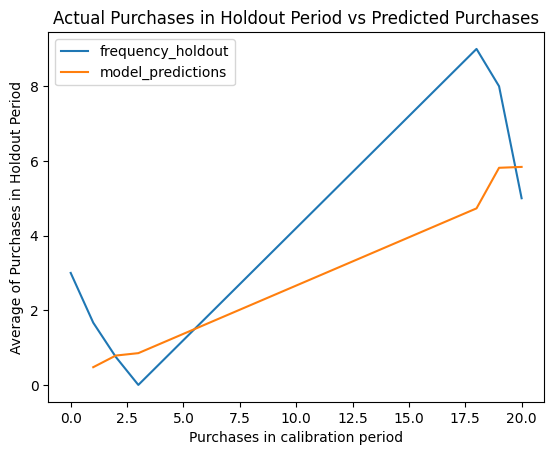

In [18]:
plot_calibration_purchases_vs_holdout_purchases(bgf, calibration_holdout_matrix)

# Fitting Gamma Gamma Model On Monetary Value

In [19]:
ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(summary['frequency'], summary['monetary_value'])

<lifetimes.GammaGammaFitter: fitted with 32 subjects, p: 1.94, q: 139.50, v: 3221.27>

In [20]:
summary[['frequency','monetary_value']].corr()

,frequency,monetary_value
frequency,1.000000,0.024154
monetary_value,0.024154,1.000000


## Calculate the CLV using both BG/NBD and Gamma-Gamma model predictions

In [21]:
summary['clv'] = ggf.customer_lifetime_value(
    bgf,  # the model to predict the number of future transactions
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=12,  # the number of time units (months, in this case) to predict CLV for
    discount_rate=0.01  # monthly discount rate
)

summary[['clv']].head()

,clv
membershipid,
1103245683,361.083825
1105161826,35.111923
1106715830,837.094030
1426869775,268.202971
2028342815,69.788780


In [22]:
summary[['frequency','recency','monetary_value','clv']]

,frequency,recency,monetary_value,clv
membershipid,,,,
1103245683,35.0,1427.0,49.034286,361.083825
1105161826,3.0,1382.0,15.750000,35.111923
1106715830,104.0,1453.0,42.783750,837.094030
1426869775,27.0,1430.0,47.404444,268.202971
2028342815,1.0,110.0,110.870000,69.788780
2033269533,3.0,155.0,42.676667,4.392335
2033269614,3.0,379.0,37.856667,20.725880
2050319341,34.0,1443.0,40.755000,323.132895
2050937124,27.0,1232.0,52.849630,307.651352


In [23]:
summary['Segment'] =  pd.qcut(summary['clv'],4,labels = ['Hibernating','Need Attention','LoyalCustomers', 'Champions'])

In [24]:
clv_segments = summary['Segment']

In [25]:
clv_segments = summary['Segment']

## Evaluating The Model

In [31]:
# Aggregate actual transactions in the holdout period
actual_revenue_holdout = df.loc[df['transaction_date'] > pd.to_datetime('2023-04-29')].groupby('membershipid')['transaction_amount'].sum()

# Join predicted CLV with the actual revenue
validation_data = summary.join(actual_revenue_holdout.rename('actual_revenue'), on='membershipid')


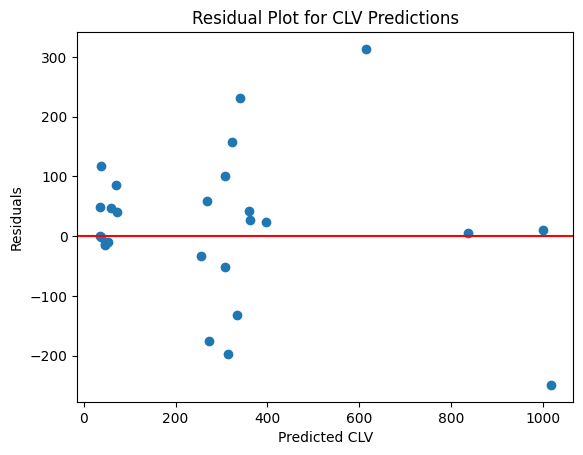

In [32]:
# Calculate residuals
validation_data['residuals'] = validation_data['actual_revenue'] - validation_data['clv']

# Plot residuals
plt.scatter(validation_data['clv'], validation_data['residuals'])
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Predicted CLV')
plt.ylabel('Residuals')
plt.title('Residual Plot for CLV Predictions')
plt.show()


In [33]:
correlation = validation_data[['clv', 'actual_revenue']].corr().iloc[0,1]
print(f"Correlation coefficient: {correlation}")


Correlation coefficient: 0.913117708419337


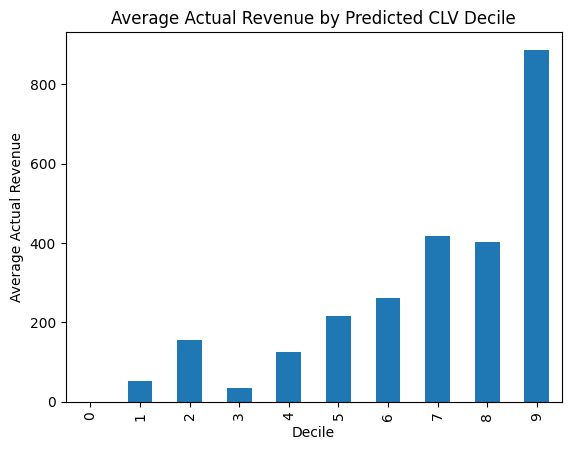

In [34]:
validation_data['decile'] = pd.qcut(validation_data['clv'], 10, labels=False)
validation_data.groupby('decile')['actual_revenue'].mean().plot(kind='bar')
plt.xlabel('Decile')
plt.ylabel('Average Actual Revenue')
plt.title('Average Actual Revenue by Predicted CLV Decile')
plt.show()
